# 07 – Model Comparison: U-Net vs DeepLabv3 (Crack Detection)

**CSE445 – Road Surface Crack Detection**

This notebook:
1. Loads the Crack Detection dataset (CRACK500 + DeepCrack)
2. Instantiates and trains **DeepLabv3** (with ResNet50 backbone) using the same pipeline & loss
3. Evaluates DeepLabv3 on the held-out test set
4. Compares **U-Net vs. DeepLabv3** head-to-head across IoU, Dice, Precision, Recall, and Accuracy

**Prerequisites**: Run `03_train_crack_unet.ipynb` & `05_evaluate_crack.ipynb` first.

In [1]:
import sys, os
try:
    from google.colab import drive
    drive.mount('/content/drive')
    REPO = '/content/drive/MyDrive/Road_Damage_Project'
    os.environ['RUN_ENV'] = 'colab'
except ImportError:
    REPO = os.path.abspath(os.path.join(os.path.dirname('__file__'), '..'))
    os.environ['RUN_ENV'] = 'local'

if REPO not in sys.path:
    sys.path.insert(0, REPO)
print('Repo root:', REPO)

Repo root: d:\Road_Damage_Project


In [2]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from tqdm import tqdm

import config
from support.shared.dataset    import SegmentationDataset
from support.shared.transforms import get_train_transforms, get_val_transforms
from support.shared.deeplabv3  import DeepLabV3Segmentation
from support.shared.unet       import UNet
from support.shared.losses     import BCEDiceLoss
from support.shared.trainer    import Trainer
from support.shared.metrics    import compute_all_metrics

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch version:', torch.__version__)
print('Device         :', device)

d:\anaconda3\envs\Thesis\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\anaconda3\envs\Thesis\lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info [ASN1: NOT_ENOUGH_DATA] not enough data (_ssl.c:4040)
  data = fetch_version_info()


PyTorch version: 2.10.0+cu130
Device         : cuda


## 1. DataLoaders

In [3]:
cfg = config.CRACK_UNET.copy()
cfg['run_name'] = 'crack_deeplabv3_run1'
img_size = (config.IMG_HEIGHT, config.IMG_WIDTH)

train_ds = SegmentationDataset(config.CRACK_SPLIT_DIR / 'train.csv', transform=get_train_transforms(img_size))
val_ds   = SegmentationDataset(config.CRACK_SPLIT_DIR / 'val.csv',   transform=get_val_transforms(img_size))
test_ds  = SegmentationDataset(config.CRACK_SPLIT_DIR / 'test.csv',  transform=get_val_transforms(img_size))

train_loader = DataLoader(train_ds, batch_size=cfg['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=cfg['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=cfg['batch_size'], shuffle=False, num_workers=2)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Train: 1982 | Val: 424 | Test: 426


## 2. DeepLabv3 Model & Trainer

In [ ]:
%load_ext autoreload
%autoreload 2
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

deeplab_model = DeepLabV3Segmentation(in_channels=3, out_channels=1, backbone='resnet50', pretrained=True)
print(f'DeepLabV3 parameters: {deeplab_model.count_parameters():,}')

loss_fn = BCEDiceLoss(bce_weight=cfg['bce_weight'], dice_weight=cfg['dice_weight'])
trainer = Trainer(deeplab_model, loss_fn, cfg, train_loader, val_loader)
print('Trainer ready. Output dir:', trainer.exp_dir)

DeepLabV3 parameters: 41,993,794
[Trainer] Using device: cuda
[Trainer] Mixed precision (AMP) enabled.
[Trainer] Config snapshot -> D:\Road_Damage_Project\experiments\crack_deeplabv3_run1\config_snapshot.json
Trainer ready. Output dir: D:\Road_Damage_Project\experiments\crack_deeplabv3_run1


## 3. Train DeepLabv3

In [5]:
# Train DeepLabv3 (pass n_epochs=None to run full 50 epochs)
history = trainer.fit(n_epochs=None)


  Starting training: crack_deeplabv3_run1
  Epochs: 50   Device: cuda   LR: 0.0002
  Early stopping patience: 10
  Output dir: D:\Road_Damage_Project\experiments\crack_deeplabv3_run1

  Ep       LR |   TrLoss   TrIoU |   VaLoss   VaIoU  VaDice |  Best?
--------------------------------------------------------------------


KeyboardInterrupt: 

## 4. Test Set Evaluation (DeepLabv3 vs U-Net)

In [8]:
# Load U-Net best checkpoint
unet_cfg  = config.CRACK_UNET
unet_ckpt = config.EXP_DIR / unet_cfg['run_name'] / 'best_model.pth'
unet_model = UNet(unet_cfg['in_channels'], unet_cfg['out_channels'], unet_cfg['base_features']).to(device)
if unet_ckpt.exists():
    unet_model.load_state_dict(torch.load(unet_ckpt, map_location=device))
    print('Loaded U-Net checkpoint:', unet_ckpt)
unet_model.eval()

# Load DeepLabV3 best checkpoint
trainer.load_best()
deeplab_model = trainer.model.to(device).eval()

def eval_model(m_obj, loader):
    res = {'iou': [], 'dice': [], 'pixel_acc': [], 'precision': [], 'recall': []}
    with torch.no_grad():
        for imgs, msks in loader:
            preds = m_obj(imgs.to(device))
            m = compute_all_metrics(preds, msks.to(device))
            for k in res: res[k].append(m[k])
    return {k: float(np.mean(v)) for k, v in res.items()}

unet_results    = eval_model(unet_model, test_loader)
deeplab_results = eval_model(deeplab_model, test_loader)

df_comp = pd.DataFrame([unet_results, deeplab_results], index=['U-Net', 'DeepLabV3'])
print('\n' + '='*60)
print('  MODEL COMPARISON ON TEST SET (CRACK DETECTION)')
print('='*60)
print(df_comp.round(4))
print('='*60)

Loaded U-Net checkpoint: D:\Road_Damage_Project\experiments\crack_unet_run1\best_model.pth
[Trainer] Loaded best checkpoint from D:\Road_Damage_Project\experiments\crack_deeplabv3_run1\best_model.pth

  MODEL COMPARISON ON TEST SET (CRACK DETECTION)
              iou    dice  pixel_acc  precision  recall
U-Net      0.5984  0.7300     0.9740     0.7214  0.7982
DeepLabV3  0.6000  0.7313     0.9752     0.7266  0.7818


## 5. Comparison Visualization

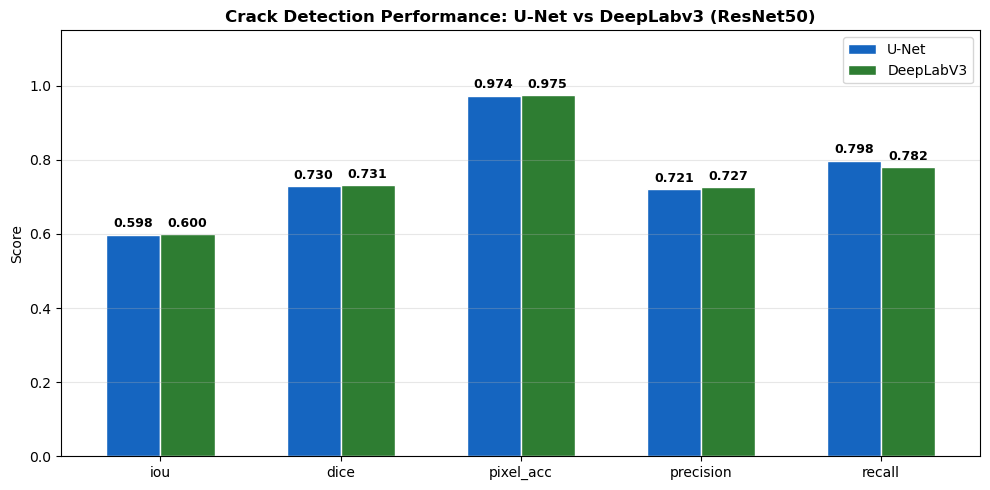

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
df_comp.T.plot(kind='bar', ax=ax, color=['#1565C0', '#2E7D32'], width=0.6, edgecolor='white')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.set_title('Crack Detection Performance: U-Net vs DeepLabv3 (ResNet50)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()